In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/cleaned/DataCoSupplyChain_Clean.csv",
    parse_dates=[
        "order date (DateOrders)",
        "shipping date (DateOrders)"
    ],
    dtype={
        "Customer Zipcode": "string"
    },
    low_memory=False
)

# Business Overview

Before investigating individual business problems, it is important to
understand the overall performance of the company.

The following KPIs provide a high-level overview.

In [6]:
total_sales = df["Sales"].sum()

total_profit = df["Benefit per order"].sum()

total_orders = df["Order Id"].nunique()

total_customers = df["Customer Id"].nunique()

avg_discount = df["Order Item Discount Rate"].mean()*100

late_delivery_rate = (
    (df["Delivery Status"]=="Late delivery").mean()*100
)

print(f"Total Sales           : ${total_sales:,.2f}")
print(f"Total Profit          : ${total_profit:,.2f}")
print(f"Total Orders          : {total_orders:,}")
print(f"Unique Customers      : {total_customers:,}")
print(f"Average Discount      : {avg_discount:.2f}%")
print(f"Late Delivery Rate    : {late_delivery_rate:.2f}%")

Total Sales           : $36,784,735.01
Total Profit          : $3,966,902.97
Total Orders          : 65,752
Unique Customers      : 20,652
Average Discount      : 10.17%
Late Delivery Rate    : 54.83%


# Sales Investigation

## 1. Which markets generate the highest revenue?

In [7]:
sales_market = (
    df.groupby("Market")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

sales_market

Market
Europe          1.087240e+07
LATAM           1.027761e+07
Pacific Asia    8.273744e+06
USCA            5.066529e+06
Africa          2.294453e+06
Name: Sales, dtype: float64

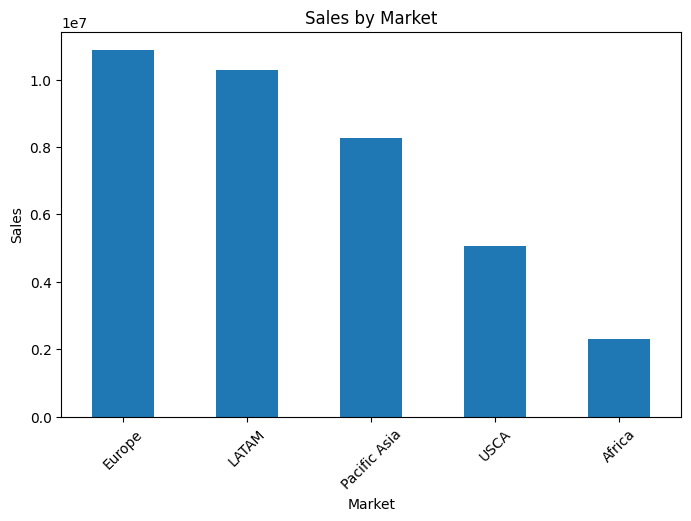

In [8]:
sales_market.plot(kind="bar", figsize=(8,5))

plt.title("Sales by Market")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

### Observation

The majority of sales are generated by LATAM and Europe.

Africa contributes the least revenue.

Recommendation:

Focus marketing campaigns and inventory planning in high-performing markets while investigating why Africa contributes significantly less.

In [9]:
sales_department = (
    df.groupby("Department Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

sales_department

Department Name
Fan Shop              1.711387e+07
Apparel               7.976255e+06
Golf                  4.609028e+06
Footwear              4.006499e+06
Outdoors              1.253351e+06
Technology            1.039599e+06
Fitness               3.970509e+05
Discs Shop            2.288877e+05
Health and Beauty     1.060805e+05
Pet Shop              4.152480e+04
Book Shop             1.258740e+04
Name: Sales, dtype: float64

In [10]:
df["Month"] = (
    df["order date (DateOrders)"]
      .dt.to_period("M")
)

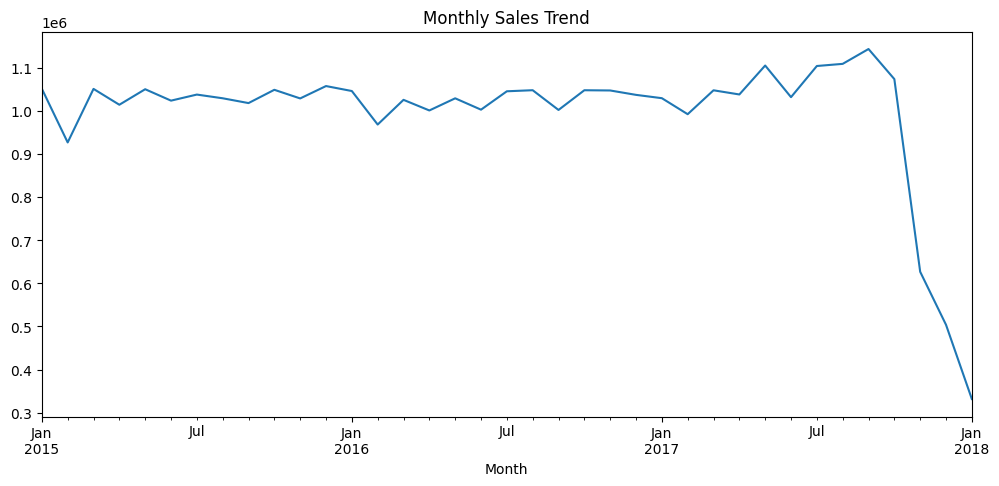

In [11]:
monthly_sales = (
    df.groupby("Month")["Sales"]
      .sum()
)

monthly_sales.plot(figsize=(12,5))

plt.title("Monthly Sales Trend")

plt.show()

## 2.Which shipping mode causes the highest late delivery rate?

In [12]:
delay_shipping = pd.crosstab(
    df["Shipping Mode"],
    df["Delivery Status"],
    normalize="index"
)*100

delay_shipping

Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Shipping Mode,,,,
First Class,0.000000,95.322499,4.677501,0.000000
Same Day,0.000000,45.743042,4.559926,49.697032
Second Class,0.000000,76.632781,4.003862,19.363358
Standard Class,38.599748,38.071683,4.268134,19.060435


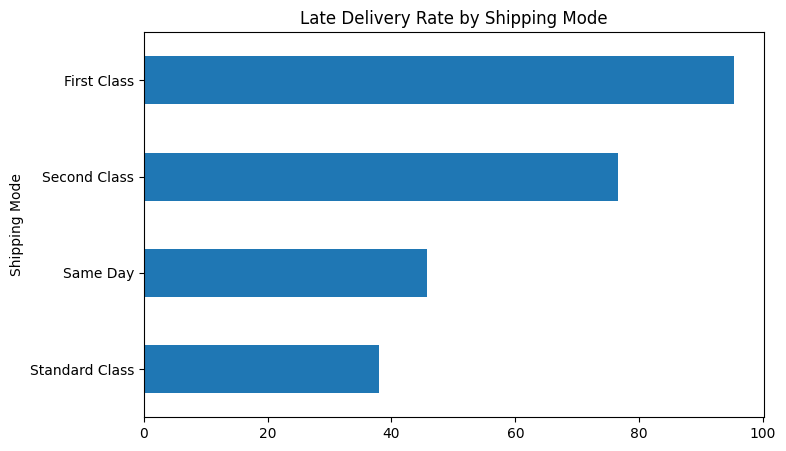

In [13]:
delay_shipping["Late delivery"].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Late Delivery Rate by Shipping Mode")

plt.show()

## 3.Which markets suffer the highest late delivery rate?

In [14]:
market_delay = pd.crosstab(
    df["Market"],
    df["Delivery Status"],
    normalize="index"
) * 100

market_delay

Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Market,,,,
Africa,22.774238,54.589289,3.960737,18.675736
Europe,23.091618,55.207753,4.302316,17.398313
LATAM,23.334109,54.355158,4.428810,17.881924
Pacific Asia,22.959283,55.046049,4.059622,17.935046
USCA,22.601651,54.800574,4.542812,18.054963


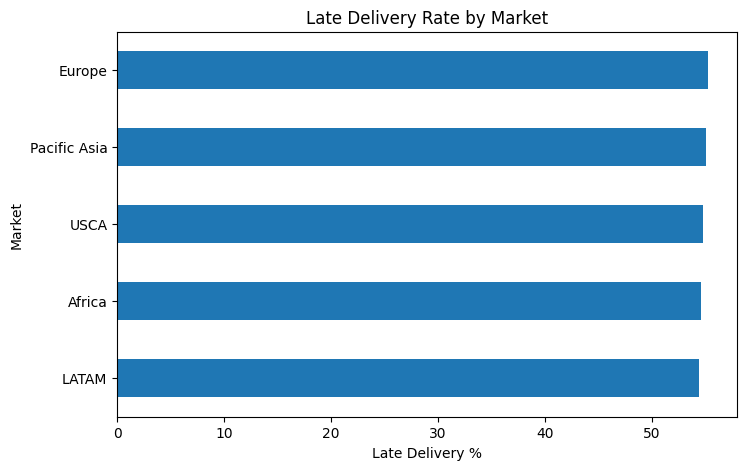

In [15]:
market_delay["Late delivery"].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Late Delivery Rate by Market")
plt.xlabel("Late Delivery %")
plt.show()

## 4.Which states generate the highest sales?

In [16]:
top_states = (
    df.groupby("Order State")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_states

Order State
Inglaterra                     1.485582e+06
Isla de Francia                1.013284e+06
California                     9.848267e+05
Renania del Norte-Westfalia    7.088903e+05
San Salvador                   6.118677e+05
Nueva York                     5.393692e+05
Distrito Federal               5.107195e+05
Texas                          4.845701e+05
Nueva Gales del Sur            4.845671e+05
Queensland                     4.328250e+05
Name: Sales, dtype: float64

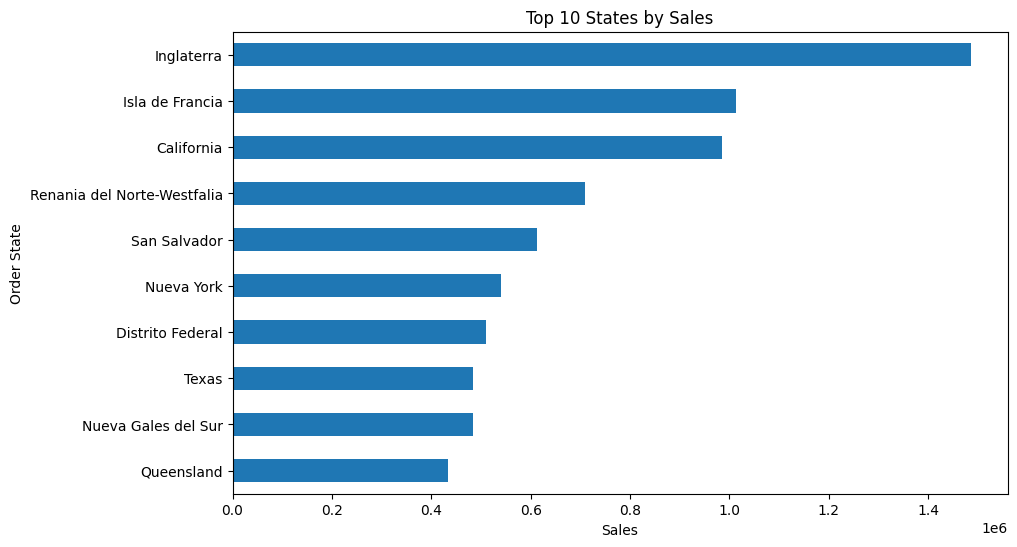

In [17]:
top_states.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 States by Sales")
plt.xlabel("Sales")
plt.show()

## 5.Which departments generate the highest profit?

In [18]:
profit_department = (
    df.groupby("Department Name")["Benefit per order"]
      .sum()
      .sort_values(ascending=False)
)

profit_department

Department Name
Fan Shop              1.834155e+06
Apparel               8.818829e+05
Golf                  4.975236e+05
Footwear              4.102225e+05
Outdoors              1.452515e+05
Technology            1.131700e+05
Fitness               4.653806e+04
Discs Shop            2.419312e+04
Health and Beauty     9.493630e+03
Pet Shop              3.589260e+03
Book Shop             8.830100e+02
Name: Benefit per order, dtype: float64

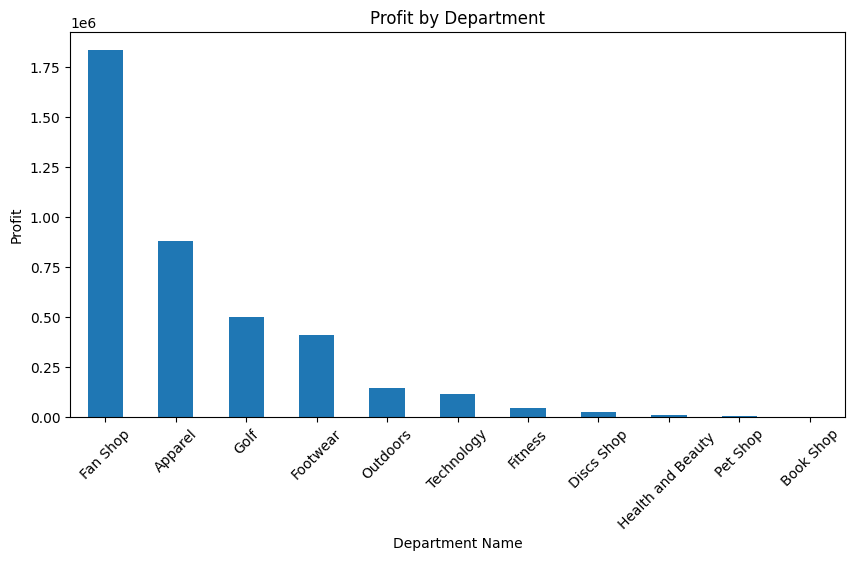

In [19]:
profit_department.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Profit by Department")
plt.xticks(rotation=45)
plt.ylabel("Profit")
plt.show()

## 6.Is the discount strategy actually profitable?

In [20]:
df["Discount Category"] = pd.cut(
    df["Order Item Discount Rate"],
    bins=[-0.01, 0, 0.10, 0.20, 0.30, 1],
    labels=[
        "No Discount",
        "0–10%",
        "10–20%",
        "20–30%",
        "Above 30%"
    ]
)

In [21]:
discount_profit = (
    df.groupby("Discount Category")["Benefit per order"]
      .mean()
)

discount_profit

C:\Users\Mangali\AppData\Local\Temp\ipykernel_14828\792230955.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Discount Category")["Benefit per order"]


Discount Category
No Discount    26.666574
0–10%          23.386170
10–20%         20.711490
20–30%         18.407092
Above 30%            NaN
Name: Benefit per order, dtype: float64

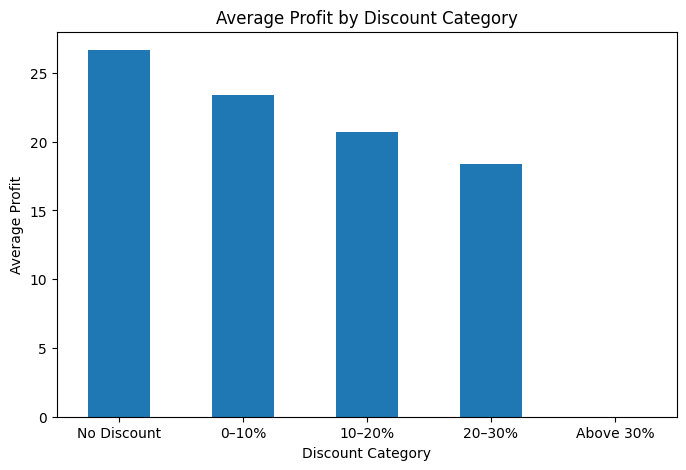

In [22]:
discount_profit.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Profit by Discount Category")
plt.ylabel("Average Profit")
plt.xticks(rotation=0)
plt.show()

## 7.Which products generate high sales but low profit?

In [24]:
product_analysis = (
    df.groupby("Product Name")
      .agg({
          "Sales":"sum",
          "Benefit per order":"sum"
      })
      .sort_values("Sales", ascending=False)
)

product_analysis.head(10)

,Sales,Benefit per order
Product Name,,
Field & Stream Sportsman 16 Gun Fire Safe,6.929654e+06,756220.767190
Perfect Fitness Perfect Rip Deck,4.421143e+06,493828.299782
Diamondback Women's Serene Classic Comfort Bi,4.118426e+06,427455.568106
Nike Men's Free 5.0+ Running Shoe,3.667633e+06,379915.818503
Nike Men's Dri-FIT Victory Golf Polo,3.147800e+06,350421.029567
Pelican Sunstream 100 Kayak,3.099845e+06,324076.370020
Nike Men's CJ Elite 2 TD Football Cleat,2.891758e+06,311902.820214
O'Brien Men's Neoprene Life Vest,2.888994e+06,318451.430554
Under Armour Girls' Toddler Spine Surge Runni,1.269083e+06,126278.510299
